In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:\data_telecom\Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
# Check for duplicates 
print(df.duplicated().sum()) 

0


In [9]:
print(df['customerID'].duplicated().sum()) 
df = df.drop_duplicates()

0


In [10]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
print(df['Churn'].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


Cleaning

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') 

In [13]:
print(df['tenure'].max())

72


In [14]:
# Create tenure buckets — this becomes a key dimension 
df['TenureBucket'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0–12 months', '13–24 months', '25–48 months', '49–72 months']) 

In [15]:
# Create binary churn column for calculations 
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int) 

In [16]:
# Flag at-risk customers (active + high-risk indicators) 
df['AtRisk'] = ( (df['Churn'] == 'No') & (df['tenure'] <= 12) & (df['Contract'] == 'Month-to-month') ).astype(int) 

In [17]:
# Analysis 1 — churn rate by contract type 
contract_churn = df.groupby('Contract')['ChurnFlag'].mean() * 100 
print(contract_churn.round(1)) 

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: ChurnFlag, dtype: float64


In [18]:
# Analysis 2 — churn rate by tenure bucket 
tenure_churn = df.groupby('TenureBucket')['ChurnFlag'].mean() * 100 
print(tenure_churn.round(1)) 

TenureBucket
0–12 months     47.7
13–24 months    28.7
25–48 months    20.4
49–72 months     9.5
Name: ChurnFlag, dtype: float64


C:\Users\darshana.kherde\AppData\Local\Temp\ipykernel_4460\1418112407.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('TenureBucket')['ChurnFlag'].mean() * 100


In [19]:
# Analysis 3 — revenue lost to churn 
revenue_lost = df[df['Churn']=='Yes']['MonthlyCharges'].sum() 
print(f'Monthly revenue lost: ${revenue_lost:,.0f}') 

Monthly revenue lost: $139,131


In [20]:
# Analysis 4 — churn by internet service type 
internet_churn = df.groupby('InternetService')['ChurnFlag'].mean() * 100 
print(internet_churn.round(1))

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: ChurnFlag, dtype: float64


In [21]:
# Replace "No internet service" and "No phone service" → "No" 
cols_to_fix = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'] 
for col in cols_to_fix: 
    df[col] = df[col].replace({ 'No internet service': 'No', 'No phone service': 'No' })

In [32]:
print(df['MonthlyCharges'].min())

18.25


In [31]:
print(df['MonthlyCharges'].max())

118.75


In [33]:
# Create charge tier — useful dimension for Power BI slicers 
df['ChargeTier'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 65, 120],
    labels=['Low (<$35)', 'Mid ($35–65)', 'High (>$65)']
)

In [23]:
# Count value-added services per customer 
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'] 
df['ServiceCount'] = df[service_cols].apply( lambda x: (x == 'Yes').sum(), axis=1)

In [24]:
# Churn by monthly charge tier 
charge_churn = df.groupby('ChargeTier')['ChurnFlag'].agg(['mean', 'count']) 
charge_churn['mean'] = (charge_churn['mean'] * 100).round(1) 
print(charge_churn)

              mean  count
ChargeTier               
Low (<$35)    10.9   1735
Mid ($35–65)  23.1   1409
High (>$65)   36.7   2997


C:\Users\darshana.kherde\AppData\Local\Temp\ipykernel_4460\771367205.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  charge_churn = df.groupby('ChargeTier')['ChurnFlag'].agg(['mean', 'count'])


ServiceCount
0    21.4
1    45.8
2    35.8
3    27.4
4    22.3
5    12.4
6     5.3
Name: ChurnFlag, dtype: float64


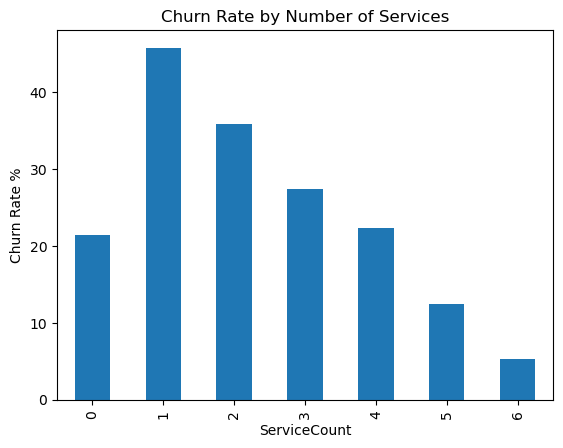

In [25]:
# Churn by service count — shows engagement impact 
service_churn = df.groupby('ServiceCount')['ChurnFlag'].mean() * 100 
print(service_churn.round(1)) 
# Visualise it 
service_churn.plot(kind='bar', title='Churn Rate by Number of Services') 
plt.ylabel('Churn Rate %') 
plt.show()

In [26]:
# Churn by payment method 
payment_churn = df.groupby('PaymentMethod')['ChurnFlag'].mean() * 100 
print(payment_churn.round(1))

PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: ChurnFlag, dtype: float64


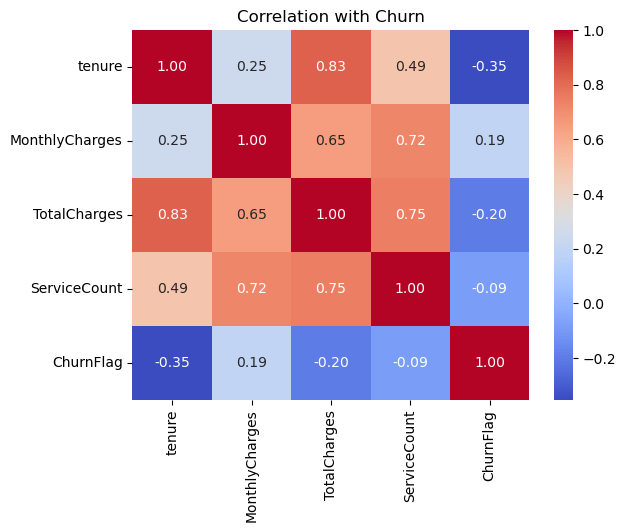

In [27]:
# Correlation heatmap — numeric columns vs ChurnFlag 
import seaborn as sns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'ChurnFlag'] 
corr = df[numeric_cols].corr() 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f') 
plt.title('Correlation with Churn') 
plt.show()

In [28]:
# Senior citizen vs non-senior churn rate 
senior_churn = df.groupby('SeniorCitizen')['ChurnFlag'].mean() * 100 
print(senior_churn.round(1)) # 0 = non-senior, 1 = senior

SeniorCitizen
0    23.6
1    41.7
Name: ChurnFlag, dtype: float64


In [34]:
df.to_csv('telco_churn_cleaned.csv', index=False)